In [1]:
from ray import tune
analysis = tune.ExperimentAnalysis("/home/alvaro-barbosa/ray_results/CNN_hp_tuning2")

2026-03-17 00:29:13,992	WARNING experiment_analysis.py:180 -- Failed to fetch metrics for 13 trial(s):
- train_CNN_eef7d_00054: FileNotFoundError('Could not fetch metrics for train_CNN_eef7d_00054: both result.json and progress.csv were not found at /home/alvaro-barbosa/ray_results/CNN_hp_tuning2/train_CNN_eef7d_00054_54_act_fun=swish,learning_rate=0.0429,n_conv_layers=4,n_filters=60,n_nodes=16,optimizer=sgdm_2026-03-16_09-55-51')
- train_CNN_eef7d_00059: FileNotFoundError('Could not fetch metrics for train_CNN_eef7d_00059: both result.json and progress.csv were not found at /home/alvaro-barbosa/ray_results/CNN_hp_tuning2/train_CNN_eef7d_00059_59_act_fun=leaky_relu,learning_rate=0.0539,n_conv_layers=5,n_filters=30,n_nodes=38,optimizer=sgd_2026-03-16_09-55-51')
- train_CNN_eef7d_00056: FileNotFoundError('Could not fetch metrics for train_CNN_eef7d_00056: both result.json and progress.csv were not found at /home/alvaro-barbosa/ray_results/CNN_hp_tuning2/train_CNN_eef7d_00056_56_act_fun=l

In [10]:
analysis.get_best_config(metric="mean_accuracy", mode='max')

{'act_fun': 'leaky_relu',
 'optimizer': 'sgd',
 'n_nodes': 32,
 'n_conv_layers': 5,
 'n_filters': 70,
 'learning_rate': 0.07753963937145553,
 'n_dense_layers': 1,
 'lambda': 0,
 'kernel_init_scale': 1,
 'use_dropout': 0,
 'input_shape': [32, 32, 3],
 'gamma': 0,
 'use_scheduler': False}

In [14]:
best = analysis.get_best_trial(metric="mean_accuracy", mode='max')

In [ ]:
best.last_result

{'keras_info': {'loss': 0.0003232052840758115,
  'accuracy': 1.0,
  'val_loss': 0.3330352008342743,
  'val_accuracy': 0.7035999894142151},
 'mean_accuracy': 0.7035999894142151,
 'mean_loss': 0.3330352008342743,
 'timestamp': 1773661282,
 'checkpoint_dir_name': None,
 'done': True,
 'training_iteration': 40,
 'trial_id': 'eef7d_00028',
 'date': '2026-03-16_12-41-22',
 'time_this_iter_s': 99.3350100517273,
 'time_total_s': 4687.604629039764,
 'pid': 123511,
 'hostname': 'AB-E14',
 'node_ip': '192.168.0.103',
 'config': {'act_fun': 'leaky_relu',
  'optimizer': 'sgd',
  'n_nodes': 32,
  'n_conv_layers': 5,
  'n_filters': 70,
  'learning_rate': 0.07753963937145553,
  'n_dense_layers': 1,
  'lambda': 0,
  'kernel_init_scale': 1,
  'use_dropout': 0,
  'input_shape': [32, 32, 3],
  'gamma': 0,
  'use_scheduler': False},
 'time_since_restore': 4687.604629039764,
 'iterations_since_restore': 40,
 'experiment_tag': '28_act_fun=leaky_relu,learning_rate=0.0775,n_conv_layers=5,n_filters=70,n_nodes=3

In [17]:
best_df = analysis.dataframe()
best_df.columns.tolist()

['mean_accuracy',
 'mean_loss',
 'timestamp',
 'checkpoint_dir_name',
 'done',
 'training_iteration',
 'trial_id',
 'date',
 'time_this_iter_s',
 'time_total_s',
 'pid',
 'hostname',
 'node_ip',
 'time_since_restore',
 'iterations_since_restore',
 'keras_info/loss',
 'keras_info/accuracy',
 'keras_info/val_loss',
 'keras_info/val_accuracy',
 'config/act_fun',
 'config/optimizer',
 'config/n_nodes',
 'config/n_conv_layers',
 'config/n_filters',
 'config/learning_rate',
 'config/n_dense_layers',
 'config/lambda',
 'config/kernel_init_scale',
 'config/use_dropout',
 'config/input_shape',
 'config/gamma',
 'config/use_scheduler',
 'logdir']

In [21]:
config_cols = [col for col in best_df.columns if col.startswith("config/")]
best_df.sort_values("mean_accuracy", ascending=False).head(15)[["mean_accuracy", "mean_loss"]+config_cols]



,mean_accuracy,mean_loss,config/act_fun,config/optimizer,config/n_nodes,config/n_conv_layers,config/n_filters,config/learning_rate,config/n_dense_layers,config/lambda,config/kernel_init_scale,config/use_dropout,config/input_shape,config/gamma,config/use_scheduler
21,0.7036,0.333035,leaky_relu,sgd,32,5,70,0.077540,1,0,1,0,"[32, 32, 3]",0,False
7,0.6944,0.357151,relu,sgd,32,4,65,0.087048,1,0,1,0,"[32, 32, 3]",0,False
12,0.6888,0.386835,leaky_relu,sgd,16,5,75,0.110539,1,0,1,0,"[32, 32, 3]",0,False
14,0.6844,0.347825,relu,sgd,20,5,80,0.073855,1,0,1,0,"[32, 32, 3]",0,False
1,0.6680,0.515333,swish,sgdm,30,4,75,0.047258,1,0,1,0,"[32, 32, 3]",0,False
11,0.6656,0.526613,relu,sgdm,20,4,45,0.058844,1,0,1,0,"[32, 32, 3]",0,False
6,0.6644,0.543090,leaky_relu,sgdm,20,4,60,0.048129,1,0,1,0,"[32, 32, 3]",0,False
24,0.6532,0.418317,leaky_relu,sgd,36,5,45,0.069437,1,0,1,0,"[32, 32, 3]",0,False
3,0.6532,0.434984,swish,sgd,30,4,45,0.082282,1,0,1,0,"[32, 32, 3]",0,False
35,0.6492,0.555228,relu,sgdm,32,3,65,0.053649,1,0,1,0,"[32, 32, 3]",0,False


In [22]:
# Which optimizer performs best on average?
print(best_df.groupby("config/optimizer")["mean_accuracy"].mean().sort_values(ascending=False))

# Which activation function?
print(best_df.groupby("config/act_fun")["mean_accuracy"].mean().sort_values(ascending=False))

config/optimizer
sgd     0.620160
sgdm    0.611752
Name: mean_accuracy, dtype: float64
config/act_fun
swish         0.623055
leaky_relu    0.617482
relu          0.607631
Name: mean_accuracy, dtype: float64


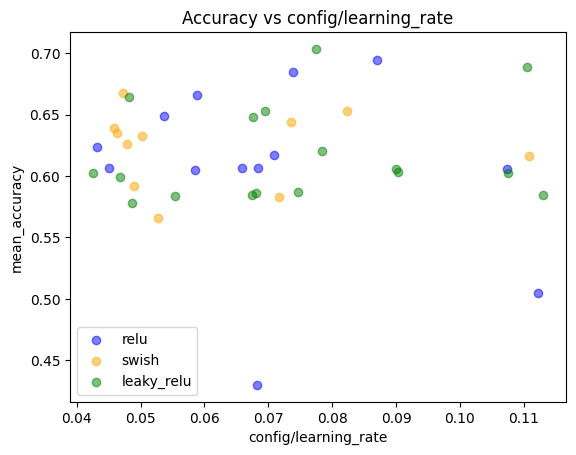

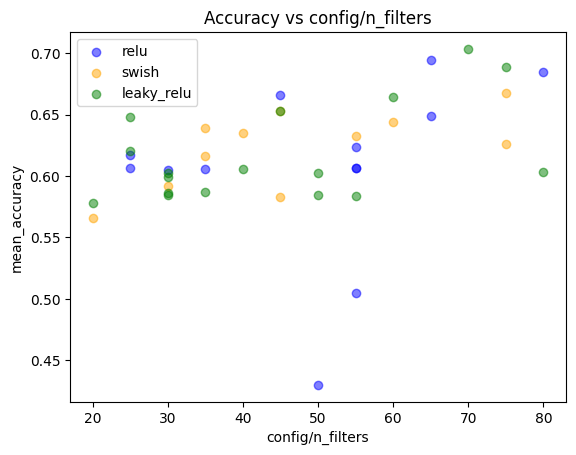

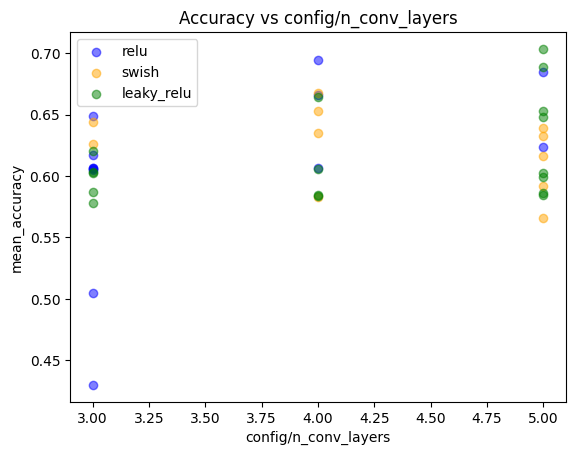

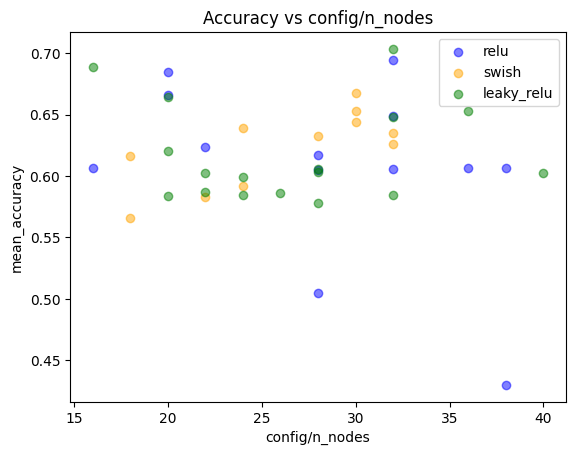

In [24]:
import matplotlib.pyplot as plt

# Filter conditions
filtered_df = best_df[
    (best_df["config/act_fun"].isin(["relu", "swish", "leaky_relu"])) &
    (best_df["config/optimizer"] != "rmsprop")
]

colors = {"relu": "blue", "swish": "orange", "leaky_relu": "green"}

for col in ["config/learning_rate", "config/n_filters", "config/n_conv_layers", "config/n_nodes"]:
    plt.figure()
    for act in ["relu", "swish", "leaky_relu"]:
        subset = filtered_df[filtered_df["config/act_fun"] == act]
        plt.scatter(subset[col], subset["mean_accuracy"], 
                   alpha=0.5, label=act, color=colors[act])
    plt.xlabel(col)
    plt.ylabel("mean_accuracy")
    plt.title(f"Accuracy vs {col}")
    plt.legend()
    plt.show()